# Whisky auction analysis
## Week 2 — pandas

Loading and exploring real whisky auction data with pandas.

In [1]:
import pandas as pd

print(pd.__version__)

3.0.1


In [2]:
import os

files = [f for f in os.listdir(".") if f.endswith(".csv")]
print(files)

['auction_data.csv', 'casks_database.csv', 'whisky.csv']


In [3]:
import os

for filename in ['auction_data.csv', 'casks_database.csv', 'whisky.csv']:
    print(f"\n--- {filename} ---")
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        print(f"Rows: {len(lines) - 1}")
        print(f"Header: {lines[0].strip()}")
        print(f"First row: {lines[1].strip()}")


--- auction_data.csv ---
Rows: 1719
Header: dt,winning_bid_max,winning_bid_min,winning_bid_mean,auction_trading_volume,auction_lots_count,all_auctions_lots_count,auction_name,auction_slug
First row: 2023-07-01,6817.6,8.9,223.53,271587.9,1215,33595,Australian Whisky Auctions,australian-whisky-auctions

--- casks_database.csv ---
Rows: 562
Header: "auction_date","distillery","region","country","strength","rla","bulk_litres","distillery_status","cask_type","cask_filling","previous_spirit","age","bottles_at_cask_strength","volume_12m","volume_6m","volume_3m","inf_adj_hammer_price","inf_adj_hammer_price_per_bottle_at_cask_strength","inf_adj_hammer_price_per_litre_of_alcohol","inf_adj_hammer_price_per_litre_of_alcohol_per_age","inf_adj_hammer_price_per_age"
First row: "2025-01-06","Bruichladdich","Islay","Scotland","50.4",74.9,"148.61","Operational","Barrel","First Fill","Bourbon",20,212.3,105,63,26,19060.19,89.78,254.48,12.72,953.01

--- whisky.csv ---
Rows: 86
Header: "RowID","Distillery"

In [4]:
df = pd.read_csv('whisky.csv')
df.head()

,RowID,Distillery,Body,Sweetness,Smoky,Medicinal,Tobacco,Honey,Spicy,Winey,Nutty,Malty,Fruity,Floral,Postcode,Latitude,Longitude
0,1,Aberfeldy,2,2,2,0,0,2,1,2,2,2,2,2,\tPH15 2EB,286580,749680
1,2,Aberlour,3,3,1,0,0,4,3,2,2,3,3,2,\tAB38 9PJ,326340,842570
2,3,AnCnoc,1,3,2,0,0,2,0,0,2,2,3,2,\tAB5 5LI,352960,839320
3,4,Ardbeg,4,1,4,4,0,0,2,0,1,2,1,0,\tPA42 7EB,141560,646220
4,5,Ardmore,2,2,2,0,0,1,1,1,2,3,1,1,\tAB54 4NH,355350,829140


In [5]:
print(df.shape)
print(df.dtypes)

(86, 17)
RowID         int64
Distillery      str
Body          int64
Sweetness     int64
Smoky         int64
Medicinal     int64
Tobacco       int64
Honey         int64
Spicy         int64
Winey         int64
Nutty         int64
Malty         int64
Fruity        int64
Floral        int64
Postcode        str
Latitude      int64
Longitude     int64
dtype: object


In [6]:
print(df.describe())

           RowID       Body  Sweetness      Smoky  Medicinal    Tobacco  \
count  86.000000  86.000000  86.000000  86.000000  86.000000  86.000000   
mean   43.500000   2.069767   2.290698   1.534884   0.546512   0.116279   
std    24.969982   0.930410   0.717287   0.863613   0.990032   0.322439   
min     1.000000   0.000000   1.000000   0.000000   0.000000   0.000000   
25%    22.250000   2.000000   2.000000   1.000000   0.000000   0.000000   
50%    43.500000   2.000000   2.000000   1.000000   0.000000   0.000000   
75%    64.750000   2.000000   3.000000   2.000000   1.000000   0.000000   
max    86.000000   4.000000   4.000000   4.000000   4.000000   1.000000   

           Honey      Spicy      Winey      Nutty      Malty     Fruity  \
count  86.000000  86.000000  86.000000  86.000000  86.000000  86.000000   
mean    1.244186   1.383721   0.976744   1.465116   1.802326   1.802326   
std     0.853175   0.784686   0.932760   0.821730   0.629094   0.779438   
min     0.000000   0.000

In [7]:
smoky = df[df["Smoky"] >= 3].sort_values("Smoky", ascending=False)
print(smoky[["Distillery", "Smoky", "Medicinal", "Body"]].to_string(index=False))

   Distillery  Smoky  Medicinal  Body
       Ardbeg      4          4     4
     Caol Ila      4          2     3
    Lagavulin      4          4     4
     Laphroig      4          4     4
      Bowmore      3          1     2
  GlenGarioch      3          0     2
    Clynelish      3          3     3
Highland Park      3          1     2
     Talisker      3          3     4


### Observation: limitations of the Smoky score

The `Smoky` score conflates several distinct characteristics — peat smoke,
maritime notes, and medicinal phenols. Domain knowledge suggests some scores
may be inaccurate (e.g. Clynelish at 3) and the dataset predates renewed
interest in Brora as a separate distillery.

This is a known limitation when working with subjective flavour scoring data.

In [8]:
islay = df[df["Distillery"].isin([
    "Ardbeg", "Laphroaig", "Lagavulin", 
    "Bowmore", "Caol Ila", "Bruichladdich",
    "Bunnahabhain", "Kilchoman"
])]

print(islay[["Distillery", "Smoky", "Medicinal", "Body", "Sweetness"]].to_string(index=False))

   Distillery  Smoky  Medicinal  Body  Sweetness
       Ardbeg      4          4     4          1
      Bowmore      3          1     2          2
Bruichladdich      2          2     1          1
 Bunnahabhain      1          1     1          2
     Caol Ila      4          2     3          1
    Lagavulin      4          4     4          1


In [9]:
flavour_cols = ["Body", "Sweetness", "Smoky", "Medicinal", 
                "Tobacco", "Honey", "Spicy", "Winey", 
                "Nutty", "Malty", "Fruity", "Floral"]

distillery_flavours = df.set_index("Distillery")[flavour_cols]

def find_similar(distillery_name, n=5):
    if distillery_name not in distillery_flavours.index:
        print(f"{distillery_name} not found in dataset")
        return
    
    target = distillery_flavours.loc[distillery_name]
    diff = distillery_flavours.subtract(target)
    distance = (diff ** 2).sum(axis=1).apply(lambda x: x ** 0.5)
    similar = distance.sort_values().iloc[1:n+1]
    
    print(f"Most similar to {distillery_name}:")
    for name, score in similar.items():
        print(f"  {name:20s}  distance: {score:.2f}")

find_similar("Ardbeg")
find_similar("Springbank")

Most similar to Ardbeg:
  Talisker              distance: 2.45
  Lagavulin             distance: 2.65
  Clynelish             distance: 2.65
  Laphroig              distance: 3.00
  Caol Ila              distance: 3.00
Most similar to Springbank:
  Bowmore               distance: 2.24
  Isle of Jura          distance: 2.24
  Highland Park         distance: 2.45
  Tomatin               distance: 2.65
  GlenScotia            distance: 2.65


In [10]:
casks = pd.read_csv('casks_database.csv')
print(casks.shape)
casks.head()

(562, 21)


,auction_date,distillery,region,country,strength,rla,bulk_litres,distillery_status,cask_type,cask_filling,...,age,bottles_at_cask_strength,volume_12m,volume_6m,volume_3m,inf_adj_hammer_price,inf_adj_hammer_price_per_bottle_at_cask_strength,inf_adj_hammer_price_per_litre_of_alcohol,inf_adj_hammer_price_per_litre_of_alcohol_per_age,inf_adj_hammer_price_per_age
0,2025-01-06,Bruichladdich,Islay,Scotland,50.40,74.90,148.61,Operational,Barrel,First Fill,...,20.0,212.30,105,63,26,19060.19,89.78,254.48,12.72,953.01
1,2025-01-06,Copper House,England,England,64.80,74.78,115.40,Operational,Barrel,NaN,...,13.0,164.86,105,63,26,1030.28,6.25,13.78,1.06,79.25
2,2025-01-06,Copper House,England,England,64.29,111.59,173.58,Operational,NaN,NaN,...,9.0,247.97,105,63,26,1030.28,4.15,9.23,1.03,114.48
3,2024-12-02,Copper House,England,England,64.29,111.59,173.58,Operational,NaN,NaN,...,9.0,247.97,132,70,45,257.19,1.04,2.30,0.26,28.58
4,2024-12-02,Bruichladdich,Islay,Scotland,53.10,115.30,217.14,Operational,Hogshead,NaN,...,NaN,310.20,132,70,45,22118.36,71.30,191.83,NaN,NaN


In [11]:
print(casks.dtypes)
print(f"\nMissing values per column:")
print(casks.isnull().sum())

auction_date                                             str
distillery                                               str
region                                                   str
country                                                  str
strength                                             float64
rla                                                  float64
bulk_litres                                          float64
distillery_status                                        str
cask_type                                                str
cask_filling                                             str
previous_spirit                                          str
age                                                  float64
bottles_at_cask_strength                             float64
volume_12m                                             int64
volume_6m                                              int64
volume_3m                                              int64
inf_adj_hammer_price    

In [12]:
scotland = casks[casks["country"] == "Scotland"].copy()

print(f"Total rows:    {len(casks)}")
print(f"Scotland only: {len(scotland)}")
print(f"Removed:       {len(casks) - len(scotland)} non-Scottish casks")

Total rows:    562
Scotland only: 482
Removed:       80 non-Scottish casks


In [13]:
print(scotland["cask_type"].value_counts())
print(f"\nUnique cask types: {scotland['cask_type'].nunique()}")
print(f"\nCask filling values:")
print(scotland["cask_filling"].value_counts())

cask_type
Hogshead        188
Barrel          163
Butt             29
Quarter Cask     28
Octave           26
Barrique         15
Name: count, dtype: int64

Unique cask types: 6

Cask filling values:
cask_filling
First Fill     128
Second Fill     61
Third Fill       3
Virgin Oak       1
Name: count, dtype: int64


In [14]:
scotland["auction_date"] = pd.to_datetime(scotland["auction_date"])

print(f"Date range: {scotland['auction_date'].min()} to {scotland['auction_date'].max()}")
print(f"\nAuctions by year:")
print(scotland["auction_date"].dt.year.value_counts().sort_index())

Date range: 2017-06-05 00:00:00 to 2025-11-23 00:00:00

Auctions by year:
auction_date
2017    13
2018    30
2019    15
2020    78
2021    87
2022    70
2023    47
2024    85
2025    57
Name: count, dtype: int64


In [15]:
print(f"Inflation-adjusted hammer price summary:")
print(f"  Min:    £{scotland['inf_adj_hammer_price'].min():>10,.0f}")
print(f"  Max:    £{scotland['inf_adj_hammer_price'].max():>10,.0f}")
print(f"  Mean:   £{scotland['inf_adj_hammer_price'].mean():>10,.0f}")
print(f"  Median: £{scotland['inf_adj_hammer_price'].median():>10,.0f}")

print(f"\nAverage price by region:")
region_prices = (scotland.groupby("region")["inf_adj_hammer_price"]
                 .agg(["mean", "count"])
                 .sort_values("mean", ascending=False)
                 .round(0))
region_prices.columns = ["avg_price", "cask_count"]
print(region_prices.to_string())

Inflation-adjusted hammer price summary:
  Min:    £       768
  Max:    £ 1,064,269
  Mean:   £    21,496
  Median: £     6,920

Average price by region:
             avg_price  cask_count
region                            
Campbeltown    78349.0          13
Speyside       31442.0         155
Islay          25333.0          79
Islands        19751.0          19
Highlands      11922.0         155
Lowlands        4013.0          61


In [16]:
expensive = scotland.nlargest(10, "inf_adj_hammer_price")

cols = ["distillery", "region", "age", "cask_type", 
        "auction_date", "inf_adj_hammer_price"]

print(expensive[cols].to_string(index=False))

distillery      region   age cask_type auction_date  inf_adj_hammer_price
  Macallan    Speyside 34.31      Butt   2022-04-24            1064268.75
  Macallan    Speyside 29.03  Hogshead   2018-02-07             322086.75
  Macallan    Speyside 30.57  Hogshead   2020-07-26             278104.95
    Ardbeg       Islay 28.00  Hogshead   2022-06-06             234790.64
  Macallan    Speyside 22.01      Butt   2018-01-03             224883.62
  Macallan    Speyside 30.15  Hogshead   2019-02-24             210948.03
  Macallan    Speyside 30.82  Hogshead   2019-10-27             206738.23
  Macallan    Speyside 28.01  Hogshead   2018-01-03             180521.55
Springbank Campbeltown 29.40  Hogshead   2022-05-29             162826.99
  Macallan    Speyside 31.24  Hogshead   2021-03-28             160029.71


In [17]:
focus = scotland[scotland["distillery"].isin(["Macallan", "Springbank", "Ardbeg"])]

distillery_stats = (focus.groupby("distillery")
                    .agg(
                        cask_count=("inf_adj_hammer_price", "count"),
                        avg_price=("inf_adj_hammer_price", "mean"),
                        median_price=("inf_adj_hammer_price", "median"),
                        avg_age=("age", "mean")
                    )
                    .round(0))

print(distillery_stats.to_string())

print(f"\nPrice per year of age:")
for distillery in ["Macallan", "Springbank", "Ardbeg"]:
    d = focus[focus["distillery"] == distillery]
    price_per_year = (d["inf_adj_hammer_price"] / d["age"]).median()
    print(f"  {distillery:12s} £{price_per_year:>8,.0f} per year of age")

            cask_count  avg_price  median_price  avg_age
distillery                                              
Ardbeg               1   234791.0      234791.0     28.0
Macallan            21   185835.0      117797.0     28.0
Springbank          12    78636.0       77662.0     27.0

Price per year of age:
  Macallan     £   4,626 per year of age
  Springbank   £   2,712 per year of age
  Ardbeg       £   8,385 per year of age


In [18]:
aged = scotland.dropna(subset=["age", "inf_adj_hammer_price"])

age_bins = [0, 10, 15, 20, 25, 30, 40, 100]
age_labels = ["<10", "10-15", "15-20", "20-25", "25-30", "30-40", "40+"]

aged["age_group"] = pd.cut(aged["age"], bins=age_bins, labels=age_labels)

age_analysis = (aged.groupby("age_group", observed=True)
                .agg(
                    count=("inf_adj_hammer_price", "count"),
                    median_price=("inf_adj_hammer_price", "median"),
                    avg_price=("inf_adj_hammer_price", "mean")
                )
                .round(0))

print(age_analysis.to_string())

           count  median_price  avg_price
age_group                                
<10          175        3452.0     4775.0
10-15        130        6783.0     9146.0
15-20         37       15674.0    16917.0
20-25         40       22789.0    40234.0
25-30         50       38975.0    59241.0
30-40         25       63295.0   118131.0


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(age_analysis.index, age_analysis["median_price"], 
            color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Median cask price by age group")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Inflation-adjusted price (£)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

import numpy as np
axes[1].bar(age_analysis.index, 
            np.log(age_analysis["median_price"]),
            color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_title("Log(median price) by age group")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("log(price)")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [20]:
import importlib
import matplotlib
print(matplotlib.__version__)

3.10.8


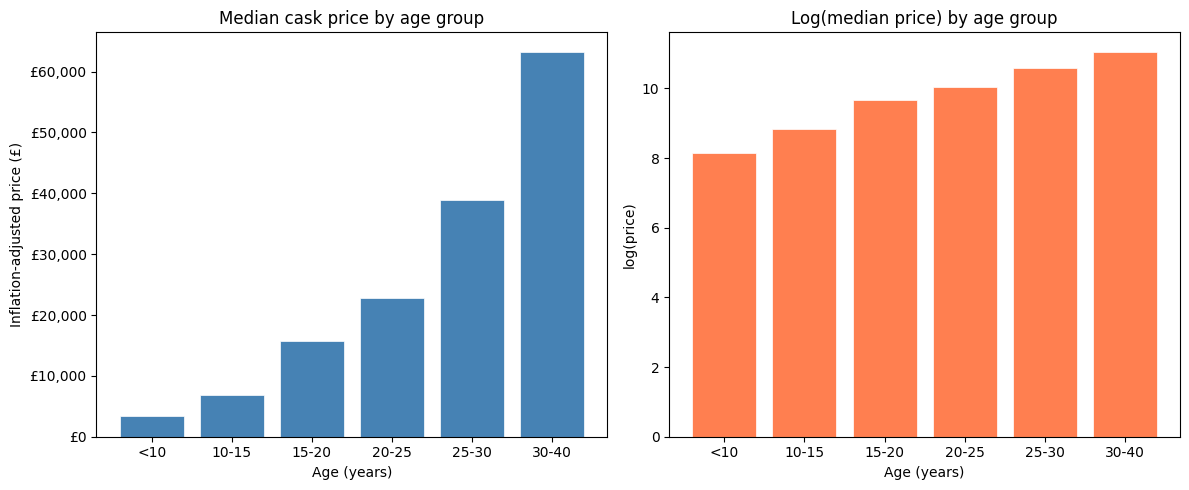

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(age_analysis.index, age_analysis["median_price"], 
            color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Median cask price by age group")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Inflation-adjusted price (£)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

import numpy as np
axes[1].bar(age_analysis.index, 
            np.log(age_analysis["median_price"]),
            color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_title("Log(median price) by age group")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("log(price)")

plt.tight_layout()
plt.show()

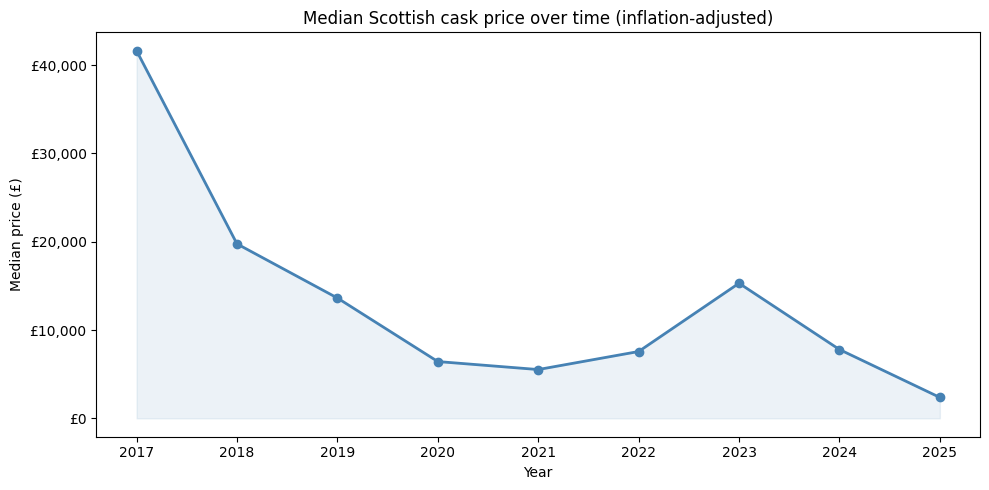

In [22]:
yearly_median = (scotland.groupby(scotland["auction_date"].dt.year)["inf_adj_hammer_price"]
                 .median()
                 .reset_index())
yearly_median.columns = ["year", "median_price"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly_median["year"], yearly_median["median_price"], 
        marker="o", linewidth=2, markersize=6, color="steelblue")

ax.fill_between(yearly_median["year"], yearly_median["median_price"], 
                alpha=0.1, color="steelblue")

ax.set_title("Median Scottish cask price over time (inflation-adjusted)")
ax.set_xlabel("Year")
ax.set_ylabel("Median price (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_xticks(yearly_median["year"])

plt.tight_layout()
plt.show()

In [23]:
yearly_counts = (scotland.groupby(scotland["auction_date"].dt.year)
                 .agg(
                     count=("inf_adj_hammer_price", "count"),
                     median_price=("inf_adj_hammer_price", "median"),
                     avg_age=("age", "mean")
                 )
                 .round(1))

print(yearly_counts.to_string())

              count  median_price  avg_age
auction_date                              
2017             13       41635.8     18.5
2018             30       19759.2     22.2
2019             15       13628.6     19.8
2020             78        6431.1     11.5
2021             87        5526.0     11.3
2022             70        7568.6     15.4
2023             47       15300.7     16.7
2024             85        7796.2     15.7
2025             57        2369.6     10.1


### Key finding: price trend is confounded by age composition

The apparent decline in median cask prices from 2017 to 2025 is largely 
explained by a shift toward younger casks being sold at auction. Average 
age of sold casks fell from 18.5 years in 2017 to 10.1 years in 2025.

Naive time series analysis of prices is misleading without controlling 
for age. A regression model controlling for age, distillery, and cask 
type is needed to isolate true market price movements — this is the goal 
of Phase 3.

In [24]:
scotland["period"] = scotland["auction_date"].dt.year.map({
    2017: "pre-covid",
    2018: "pre-covid",
    2019: "pre-covid",
    2020: "covid-boom",
    2021: "covid-boom",
    2022: "post-covid",
    2023: "post-covid",
    2024: "post-covid",
    2025: "post-covid"
})

period_stats = (scotland.groupby("period")
                .agg(
                    count=("inf_adj_hammer_price", "count"),
                    median_price=("inf_adj_hammer_price", "median"),
                    avg_age=("age", "mean"),
                    median_price_per_age=("inf_adj_hammer_price_per_age", "median")
                )
                .round(1))

order = ["pre-covid", "covid-boom", "post-covid"]
print(period_stats.loc[order].to_string())

            count  median_price  avg_age  median_price_per_age
period                                                        
pre-covid      58       16875.1     20.7                 931.4
covid-boom    165        6017.2     11.4                 709.2
post-covid    259        6481.0     14.6                 681.6


In [25]:
scotland["period"] = scotland["auction_date"].dt.year.map({
    2017: "pre-covid",
    2018: "pre-covid",
    2019: "pre-covid",
    2020: "covid-boom",
    2021: "covid-boom",
    2022: "covid-boom",
    2023: "covid-boom",
    2024: "post-covid",
    2025: "post-covid"
})

period_stats = (scotland.groupby("period")
                .agg(
                    count=("inf_adj_hammer_price", "count"),
                    median_price=("inf_adj_hammer_price", "median"),
                    avg_age=("age", "mean"),
                    median_price_per_age=("inf_adj_hammer_price_per_age", "median")
                )
                .round(1))

order = ["pre-covid", "covid-boom", "post-covid"]
print(period_stats.loc[order].to_string())

            count  median_price  avg_age  median_price_per_age
period                                                        
pre-covid      58       16875.1     20.7                 931.4
covid-boom    282        7148.7     13.3                 745.3
post-covid    142        3739.9     13.5                 556.6


### Market trend: age-adjusted price by period

Price per year of age declined consistently from pre-COVID through post-COVID,
suggesting genuine market softening beyond compositional effects.

Periodisation note: 2022-2023 classified as covid-boom rather than post-covid
because stimulus effects and market liquidity persisted through this period.
Two periodisations were tested — conclusions are consistent across both but
the effect is cleaner when 2022-2023 is included in the boom period.

Pre-covid:  £931/year of age
Covid-boom: £745/year of age  (−20%)
Post-covid: £557/year of age  (−40% from baseline)

### Market context: Hong Kong and the post-COVID cask market

The post-2022 decline in age-adjusted cask prices likely reflects several 
overlapping factors:

1. End of pandemic-era stimulus driving speculative investment in tangible assets
2. Demographic contraction in Hong Kong — a major Asian whisky hub — due to 
   political change and emigration of affluent collectors post-2019
3. Market segmentation: cask auctions (this dataset) represent the volume/
   investment segment, which is more sensitive to macroeconomic conditions than 
   the ultra-premium collector segment (private sales, enthusiast events)

The whisky market has not uniformly declined — rather, different segments are 
behaving differently. This dataset captures the segment most affected by the 
post-COVID correction.

Source: domain knowledge, whisky retailer anecdote, WhiskyNow event data

In [26]:
import requests

response = requests.get("https://whiskyhunter.net/api/distilleries_info/")
print(f"Status code: {response.status_code}")
print(response.text[:500])

Status code: 200
[{"name":"8 Doors Distillery","slug":"8_doors","country":"Scotland"},{"name":"Abbeyhill Distillery","slug":"abbeyhill","country":"Scotland"},{"name":"Aberargie Distillery","slug":"aberargie","country":"Scotland"},{"name":"Aberfeldy","slug":"aberfeldy","country":"Scotland"},{"name":"Aberlour","slug":"aberlour","country":"Scotland"},{"name":"Abhainn Dearg","slug":"abhainn_dearg","country":"Scotland"},{"name":"Ailsa Bay","slug":"ailsa_bay","country":"Scotland"},{"name":"Aioi Unibio Co. Ltd.","slug"


In [27]:
import requests
import json

response = requests.get("https://whiskyhunter.net/api/distilleries_info/")
distilleries = response.json()

print(f"Total distilleries: {len(distilleries)}")
print(f"\nFirst entry in full:")
print(json.dumps(distilleries[0], indent=2))

scottish = [d for d in distilleries if d["country"] == "Scotland"]
print(f"\nScottish distilleries: {len(scottish)}")

springbank = requests.get("https://whiskyhunter.net/api/distillery_data/springbank/")
print(f"\nSpringbank endpoint status: {springbank.status_code}")
print(json.dumps(springbank.json()[:2], indent=2))

Total distilleries: 313

First entry in full:
{
  "name": "8 Doors Distillery",
  "slug": "8_doors",
  "country": "Scotland"
}

Scottish distilleries: 250

Springbank endpoint status: 200
[
  {
    "dt": "2024-03-01",
    "winning_bid_max": 11875.0,
    "winning_bid_min": 2.0,
    "winning_bid_mean": 330.84,
    "trading_volume": 527360.2,
    "lots_count": 1062,
    "slug": "springbank",
    "name": "Springbank"
  },
  {
    "dt": "2024-02-01",
    "winning_bid_max": 18612.0,
    "winning_bid_min": 11.5,
    "winning_bid_mean": 436.6,
    "trading_volume": 606444.01,
    "lots_count": 823,
    "slug": "springbank",
    "name": "Springbank"
  }
]


In [28]:
auctions = requests.get("https://whiskyhunter.net/api/auctions_info/")
print(f"Status: {auctions.status_code}")
print(json.dumps(auctions.json()[:2], indent=2))

auction_data = requests.get("https://whiskyhunter.net/api/auctions_data/")
print(f"\nAuctions data status: {auction_data.status_code}")
print(json.dumps(auction_data.json()[:2], indent=2))

Status: 404


JSONDecodeError: Expecting value: line 4 column 1 (char 3)

In [29]:
auctions = requests.get("https://whiskyhunter.net/api/auctions_info/")
print(f"Status: {auctions.status_code}")
print(json.dumps(auctions.json()[:2], indent=2))

auction_data = requests.get("https://whiskyhunter.net/api/auctions_data/")
print(f"\nAuctions data status: {auction_data.status_code}")
print(json.dumps(auction_data.json()[:2], indent=2))

Status: 404


JSONDecodeError: Expecting value: line 4 column 1 (char 3)

In [30]:
auctions = requests.get("https://whiskyhunter.net/api/auctions_info/")
print(f"Status: {auctions.status_code}")
print(f"Raw response:\n{auctions.text[:500]}")

Status: 404
Raw response:



<!DOCTYPE html>
<html lang="en">

<head>
  
  

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
<meta name="format-detection" content="telephone=no"/>
<meta name="referrer" content="same-origin">



<link rel="icon" type="image/png" href="/static/favicon.png"/>
<link rel="apple-touch-icon" sizes="180x180" href="/static/apple-touch-icon-180x180.png">


  <title>
    
Error 404

  </title>

  
    <style>
    *{
    transition: all 0


In [31]:
endpoints = [
    "distilleries_info/",
    "distillery_data/springbank/",
    "auctions_info/",
    "auctions_data/",
    "auction_data/",
    "lots/",
    "bottles/",
]

base = "https://whiskyhunter.net/api/"

for endpoint in endpoints:
    r = requests.get(base + endpoint)
    preview = r.text.strip()[:80] if r.status_code == 200 else ""
    print(f"{r.status_code}  {endpoint:35s}  {preview}")

200  distilleries_info/                   [{"name":"8 Doors Distillery","slug":"8_doors","country":"Scotland"},{"name":"Ab
200  distillery_data/springbank/          [{"dt":"2024-03-01","winning_bid_max":11875.0,"winning_bid_min":2.0,"winning_bid
404  auctions_info/                       
200  auctions_data/                       [{"dt":"2024-03-01","winning_bid_mean":204.82,"auction_trading_volume":259096.9,
404  auction_data/                        
404  lots/                                
404  bottles/                             


In [32]:
for endpoint in endpoints:
    r = requests.get(base + endpoint)
    preview = r.text.strip()[:80] if r.status_code == 200 else ""
    print(f"{r.status_code}  {endpoint:35s}  {preview}")  # indented

200  distilleries_info/                   [{"name":"8 Doors Distillery","slug":"8_doors","country":"Scotland"},{"name":"Ab
200  distillery_data/springbank/          [{"dt":"2024-03-01","winning_bid_max":11875.0,"winning_bid_min":2.0,"winning_bid
404  auctions_info/                       
200  auctions_data/                       [{"dt":"2024-03-01","winning_bid_mean":204.82,"auction_trading_volume":259096.9,
404  auction_data/                        
404  lots/                                
404  bottles/                             


In [33]:
r = requests.get("https://whiskyhunter.net/api/auctions_data/")
data = r.json()
print(f"Records: {len(data)}")
print(json.dumps(data[0], indent=2))

Records: 1994
{
  "dt": "2024-03-01",
  "winning_bid_mean": 204.82,
  "auction_trading_volume": 259096.9,
  "auction_lots_count": 1265,
  "all_auctions_lots_count": 44035,
  "auction_name": "Australian Whisky Auctions",
  "auction_slug": "australian-whisky-auctions"
}


In [34]:
response = requests.get("https://www.scotchwhiskyauctions.com/auctions/")
print(response.status_code)
print(response.text[:3000])

200
<!DOCTYPE html>
<html lang="en">
<head>
<title>All auctions | Scotch Whisky Auctions</title>
<meta http-equiv="Content-Type" content="text/html; charset=utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0">
<meta name="apple-itunes-app" content="app-id=662851101">
<base href="https://www.scotchwhiskyauctions.com/">
<link rel="stylesheet" type="text/css" href="/templates/swa.max.css?0911a" media="all">
<link rel="image_src" href="https://d3suvtcq00dftb.cloudfront.net/images/5a24387e5900d2db8ca09d89eb28933d-med.jpg">

<meta property="og:site_name" content="Scotch Whisky Auctions"><meta property="og:title" content="All auctions"><meta property="og:image" content="https://www.scotchwhiskyauctions.com/https://d3suvtcq00dftb.cloudfront.net/images/5a24387e5900d2db8ca09d89eb28933d-med.jpg">
<script async src="https://www.googletagmanager.com/gtag/js?id=G-065PL0LN18"></script>
<script>
  window.dataLayer = window.dataLayer || [];
  function gtag()

In [35]:
from bs4 import BeautifulSoup

response = requests.get("https://www.scotchwhiskyauctions.com/auctions/")
soup = BeautifulSoup(response.text, "html.parser")

auction_links = soup.find_all("a", href=True)
auction_links = [a for a in auction_links if "/auctions/" in a["href"] 
                 and a["href"] != "/auctions/"
                 and "current" not in a["href"]]

for link in auction_links[:20]:
    print(f"{link['href']:60s}  {link.text.strip()[:40]}")


/auctions/#menu                                               Skip to menu
/auctions/#contentstart                                       Skip to content
/auctions/226-the-177th-auction/                              The 177th AuctionEnds March 8, 2026There
/auctions/225-the-176th-auction/                              The 176th AuctionEnded February 8, 2026T
/auctions/224-the-175th-auction/                              The 175th AuctionEnded January 11, 2026T
/auctions/223-the-174th-auction/                              The 174th AuctionEnded December 7, 2025T
/auctions/222-the-173rd-auction/                              The 173rd AuctionEnded November 9, 2025T
/auctions/221-the-172nd-auction/                              The 172nd AuctionEnded October 12, 2025T
/auctions/220-the-171st-auction/                              The 171st AuctionEnded September 14, 202
/auctions/219-the-170th-auction/                              The 170th AuctionEnded August 10, 2025Th
/auctions/218-the-169th

In [36]:
response = requests.get("https://www.scotchwhiskyauctions.com/auctions/226-the-177th-auction/")
soup = BeautifulSoup(response.text, "html.parser")

lot_links = soup.find_all("a", href=True)
lot_links = [a for a in lot_links 
             if "/auctions/226-" in a["href"]
             and a["href"] != "/auctions/226-the-177th-auction/"]

print(f"Lot links found: {len(lot_links)}")
for link in lot_links[:10]:
    print(f"{link['href'][:80]}")

Lot links found: 26
/auctions/226-the-177th-auction/#menu
/auctions/226-the-177th-auction/#contentstart
/auctions/226-the-177th-auction/866230-littlemill-1976-testament-to-the-past-wit
/auctions/226-the-177th-auction/862557-highland-park-50-year-old-2020-release/
/auctions/226-the-177th-auction/862100-glenturret-30-year-old/
/auctions/226-the-177th-auction/862645-macallan-fine--rare-1949-53-year-old/
/auctions/226-the-177th-auction/867182-highland-park-2003-22-year-old-integrity-
/auctions/226-the-177th-auction/867123-2bar-spirits-2018-4-year-old-bourbon-red-
/auctions/226-the-177th-auction/867122-2bar-spirits-2018-4-year-old-bourbon-red-
/auctions/226-the-177th-auction/867124-2bar-spirits-2018-4-year-old-bourbon-red-


In [37]:
response = requests.get("https://www.scotchwhiskyauctions.com/auctions/226-the-177th-auction/")
soup = BeautifulSoup(response.text, "html.parser")

pagination = soup.find_all("a", href=True)
pagination = [a for a in pagination if "page=" in a["href"]]

for link in pagination[:10]:
    print(f"{link['href']}")

print("\n--- Also checking total lot count ---")
page_text = soup.get_text()
lines = [l.strip() for l in page_text.split("\n") if l.strip()]
for line in lines:
    if any(word in line.lower() for word in ["lot", "result", "found", "total"]):
        print(line[:100])


--- Also checking total lot count ---
Now for something special from the far north, this is the Highland Park 50 Year Old 2020 Release.  T
As always we have an enormous selection of drams to suit every budget on offer this month, so now is


In [38]:
response = requests.get(
    "https://www.scotchwhiskyauctions.com/auctions/226-the-177th-auction/",
    params={"page": 2}
)
soup = BeautifulSoup(response.text, "html.parser")

lot_links = [a["href"] for a in soup.find_all("a", href=True)
             if "/auctions/226-" in a["href"]
             and "#" not in a["href"]
             and a["href"] != "/auctions/226-the-177th-auction/"]

print(f"Lots on page 2: {len(lot_links)}")
for link in lot_links[:5]:
    print(link)

Lots on page 2: 24
/auctions/226-the-177th-auction/866230-littlemill-1976-testament-to-the-past-with-matching-mini-5cl/
/auctions/226-the-177th-auction/862557-highland-park-50-year-old-2020-release/
/auctions/226-the-177th-auction/862100-glenturret-30-year-old/
/auctions/226-the-177th-auction/862645-macallan-fine--rare-1949-53-year-old/
/auctions/226-the-177th-auction/866892-aberlour-12-year-old-double-cask-matured/


In [39]:
for param in ["page", "p", "start", "offset"]:
    r = requests.get(
        "https://www.scotchwhiskyauctions.com/auctions/226-the-177th-auction/",
        params={param: 2}
    )
    soup = BeautifulSoup(r.text, "html.parser")
    lots = [a["href"] for a in soup.find_all("a", href=True)
            if "/auctions/226-" in a["href"]
            and "#" not in a["href"]
            and a["href"] != "/auctions/226-the-177th-auction/"]
    print(f"param={param:10s}  lots found: {len(lots)}")

param=page        lots found: 24
param=p           lots found: 0
param=start       lots found: 24
param=offset      lots found: 24


In [40]:
import requests
from bs4 import BeautifulSoup

r = requests.get(
    "https://www.scotchwhiskyauctions.com/auctions/226-the-177th-auction/",
    headers={
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    }
)
soup = BeautifulSoup(r.text, "html.parser")

lot_links = [a["href"] for a in soup.find_all("a", href=True)
             if "/auctions/226-" in a["href"]
             and "#" not in a["href"]
             and a["href"] != "/auctions/226-the-177th-auction/"]

print(f"Lots found: {len(lot_links)}")

scripts = soup.find_all("script")
print(f"\nScript tags: {len(scripts)}")
for s in scripts:
    if s.string and "lot" in s.string.lower()[:500]:
        print(s.string[:300])

Lots found: 24

Script tags: 8


In [41]:
import time

base = "https://www.scotchwhiskyauctions.com/auctions/226-the-177th-auction/"

found = []
not_found = []

for lot_id in range(867120, 867135):
    r = requests.get(f"{base}{lot_id}/")
    if r.status_code == 200 and "Winning bid" in r.text:
        soup = BeautifulSoup(r.text, "html.parser")
        title = soup.find("h1")
        print(f"FOUND {lot_id}: {title.text.strip()[:60] if title else 'no title'}")
        found.append(lot_id)
    else:
        not_found.append(lot_id)
    time.sleep(1)

print(f"\nFound: {len(found)}  Not found: {len(not_found)}")

FOUND 867120: Santa Fe Spirits 2017 6 Year Old Mesquite Smoked American Si
FOUND 867121: Santa Fe Spirits 2017 6 Year Old Mesquite Smoked American Si
FOUND 867122: 2Bar Spirits 2018 4 Year Old Bourbon Red Wine Barrel America
FOUND 867123: 2Bar Spirits 2018 4 Year Old Bourbon Red Wine Barrel America
FOUND 867124: 2Bar Spirits 2018 4 Year Old Bourbon Red Wine Barrel America
FOUND 867125: Heritage Distilling Co. 2015 6 Year Old 100% Rye Whiskey Ame
FOUND 867126: Heritage Distilling Co. 2015 6 Year Old 100% Rye Whiskey Ame
FOUND 867127: Heritage Distilling Co. 2015 6 Year Old 100% Rye Whiskey Ame
FOUND 867128: Copperworks Distilling Co. 2017 6 Year Old American Single M
FOUND 867129: Copperworks Distilling Co. 2017 6 Year Old American Single M
FOUND 867130: Copperworks Distilling Co. 2017 6 Year Old American Single M
FOUND 867131: Heritage Distilling Co. 2018 5 Year Old Chocolate Malted Bar
FOUND 867132: Heritage Distilling Co. 2018 5 Year Old Chocolate Malted Bar
FOUND 867134: Springbank 